## p50 Little Image denoising exermple

```
conda activate sora
```

In [1]:
# PROMPT = "a gray tabby cat sitting on a windowsill, golden hour light, photorealistic"

In [2]:
# from huggingface_hub import notebook_login

# notebook_login()

In [11]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from PIL import Image
from pathlib import Path

PROMPT = "A happy gray tabby cat looking at the camera, photorealistic, 8k"
NEGATIVE_PROMPT = "cartoon, illustration, painting, drawing, anime, low quality"
SEED = 5 #12 is ok
NUM_STEPS = 100
GUIDANCE_SCALE = 7.0
OUTPUT_DIR = Path("/home/stephen/robots/mar_17_2")
OUTPUT_DIR.mkdir(exist_ok=True)

pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE",
    torch_dtype=torch.float16,
)
# Better scheduler for photorealism
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
)
pipe.to("cuda")

intermediate_latents = []

def capture_latents(pipe, step_index, timestep, callback_kwargs):
    intermediate_latents.append(callback_kwargs["latents"].detach().clone())
    return callback_kwargs

generator = torch.Generator(device="cuda").manual_seed(SEED)

result = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    num_inference_steps=NUM_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
    callback_on_step_end=capture_latents,
)

final_image = result.images[0]
final_image.save(OUTPUT_DIR / "final.png")

# --- Decode intermediates (SD1.5 VAE is tiny, no VRAM issues) ---
step_images = []
for i, latents in enumerate(intermediate_latents):
    with torch.no_grad():
        decoded = pipe.vae.decode(latents / pipe.vae.config.scaling_factor, return_dict=False)[0]
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        img = decoded[0].permute(1, 2, 0).cpu().float().numpy()
        img = Image.fromarray((img * 255).astype("uint8"))
    step_images.append(img)
    img.save(OUTPUT_DIR / f"step_{i:03d}.png")

print(f"Done — {len(step_images)} steps to {OUTPUT_DIR}/")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Done — 100 steps to /home/stephen/robots/mar_17_2/


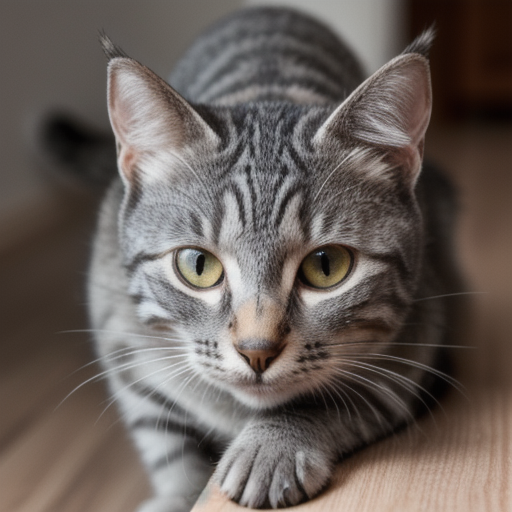

In [12]:
final_image

---

In [2]:
import torch
from diffusers import FluxPipeline

pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.bfloat16)
pipe.enable_model_cpu_offload() #save some VRAM by offloading the model to CPU. Remove this if you have enough GPU power

prompt = "A cat holding a sign that says hello world"
image = pipe(
    prompt,
    height=1024,
    width=1024,
    guidance_scale=3.5,
    num_inference_steps=50,
    max_sequence_length=512,
    generator=torch.Generator("cpu").manual_seed(0)
).images[0]
image.save("flux-dev.png")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


  0%|          | 0/50 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 54.00 MiB. GPU 0 has a total capacity of 23.56 GiB of which 74.88 MiB is free. Including non-PyTorch memory, this process has 22.97 GiB memory in use. Of the allocated memory 22.46 GiB is allocated by PyTorch, and 217.57 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [1]:
from diffusers import FluxPipeline, FluxTransformer2DModel
from transformers import BitsAndBytesConfig
import torch

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Load transformer quantized, then plug it into the pipeline
transformer = FluxTransformer2DModel.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="transformer",
    quantization_config=nf4_config,
    torch_dtype=torch.bfloat16,
)

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    transformer=transformer,
    torch_dtype=torch.bfloat16,
)
pipe.to("cuda")

PackageNotFoundError: No package metadata was found for bitsandbytes

In [5]:
# import torch
# from diffusers import FluxPipeline
# from PIL import Image
# from pathlib import Path

# --- Config ---
PROMPT = "a gray tabby cat sitting on a windowsill, golden hour light, photorealistic"
SEED = 42
NUM_STEPS = 30
GUIDANCE_SCALE = 3.5  # FLUX likes lower guidance than SD
OUTPUT_DIR = Path("/home/stephen/robots/mar_17_1")
OUTPUT_DIR.mkdir(exist_ok=True)


In [2]:
# --- Load pipeline ---
pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16,  # FLUX prefers bf16
)
# pipe.enable_model_cpu_offload()

# pipe.to("cuda")

pipe.enable_model_cpu_offload()
# If tight on VRAM, uncomment:
# pipe.enable_model_cpu_offload()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [3]:
# --- Capture intermediates ---
intermediate_latents = []

def capture_latents(pipe, step_index, timestep, callback_kwargs):
    intermediate_latents.append(callback_kwargs["latents"].detach().clone())
    return callback_kwargs

In [4]:
# --- Generate ---
generator = torch.Generator(device="cuda").manual_seed(SEED)

result = pipe(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
    callback_on_step_end=capture_latents,
)

final_image = result.images[0]
final_image.save(OUTPUT_DIR / "final.png")

  0%|          | 0/30 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 136.00 MiB. GPU 0 has a total capacity of 23.56 GiB of which 154.88 MiB is free. Including non-PyTorch memory, this process has 22.90 GiB memory in use. Of the allocated memory 22.37 GiB is allocated by PyTorch, and 230.62 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
final_image

In [ ]:
# --- Decode intermediates ---
print(f"Decoding {len(intermediate_latents)} steps...")

step_images = []
for i, latents in enumerate(intermediate_latents):
    with torch.no_grad():
        # FLUX uses the same VAE decode pattern
        latents_scaled = (latents / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
        decoded = pipe.vae.decode(latents_scaled, return_dict=False)[0]
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        img = decoded[0].permute(1, 2, 0).cpu().float().numpy()
        img = Image.fromarray((img * 255).astype("uint8"))

    step_images.append(img)
    img.save(OUTPUT_DIR / f"step_{i:03d}.png")

print(f"Done — {len(step_images)} steps saved to {OUTPUT_DIR}/")